# FlowPost: PostNet uncertainty + Flow Matching TX
**Kaggle setup (Add Input):** `harshadakhatu/cifar-10-c`, `zahwayounus/new-data`, `zahwayounus/postnet-final`. GPU on.

Run top to bottom. Phase 1 data generation is skipped by default because `new-data` already holds its output.

In [ ]:
# Config
RUN_PHASE1 = False   # True only if you need to regenerate flowpost_data (slow, writes ~GBs)

## 0. Dataset sanity check

In [ ]:
# CIFAR-10-C Sanity Check
# Run this in your Kaggle notebook after adding the harshadakhatu/cifar-10-c dataset.

import os
import numpy as np

DATA_DIR = "/kaggle/input/datasets/harshadakhatu/cifar-10-c/CIFAR-10-C"

# Expected: 19 corruption types (CIFAR-10-C standard set)
EXPECTED_CORRUPTIONS = [
    "gaussian_noise", "shot_noise", "impulse_noise",
    "defocus_blur", "glass_blur", "motion_blur", "zoom_blur",
    "snow", "frost", "fog", "brightness",
    "contrast", "elastic_transform", "pixelate", "jpeg_compression",
    "speckle_noise", "gaussian_blur", "spatter", "saturate",
]

def main():
    print(f"Looking in: {DATA_DIR}\n")

    if not os.path.exists(DATA_DIR):
        print("ERROR: Data directory not found. Did you add the dataset via 'Add Input'?")
        return

    files = os.listdir(DATA_DIR)
    npy_files = [f for f in files if f.endswith(".npy")]
    print(f"Found {len(npy_files)} .npy files:")
    for f in sorted(npy_files):
        print(f"  - {f}")
    print()

    # Check for labels file
    if "labels.npy" in npy_files:
        labels = np.load(os.path.join(DATA_DIR, "labels.npy"))
        print(f"labels.npy shape: {labels.shape}, unique classes: {np.unique(labels).size}\n")
    else:
        print("WARNING: labels.npy not found — check filename variants.\n")

    # Check each expected corruption type
    missing = []
    found_summary = []

    for corruption in EXPECTED_CORRUPTIONS:
        fname = f"{corruption}.npy"
        fpath = os.path.join(DATA_DIR, fname)
        if os.path.exists(fpath):
            arr = np.load(fpath, mmap_mode="r")  # mmap avoids loading full array into RAM
            found_summary.append((corruption, arr.shape))
        else:
            missing.append(corruption)

    print("=== Found corruption types ===")
    for name, shape in found_summary:
        # CIFAR-10-C convention: 50,000 images per corruption = 10,000 images x 5 severities
        n_images = shape[0]
        expected_per_severity = n_images // 5 if n_images % 5 == 0 else None
        severity_ok = "OK (5 severities x 10k)" if n_images == 50000 else f"CHECK: got {n_images} images, expected 50000"
        print(f"  {name:20s} shape={shape}  {severity_ok}")

    print(f"\n=== Missing corruption types ({len(missing)}) ===")
    if missing:
        for m in missing:
            print(f"  - {m}")
    else:
        print("  None — all 19 standard corruption types present.")

    print("\n=== Verdict ===")
    if not missing and found_summary and all(s[1][0] == 50000 for s in found_summary):
        print("Dataset looks complete and correctly shaped. Safe to proceed.")
    else:
        print("Dataset is incomplete or misshapen. Fall back to the official Zenodo source:")
        print("https://zenodo.org/record/2535967")

if __name__ == "__main__":
    main()

## 1. Phase 1: simulator and calibration data

In [ ]:
# Phase 1 — Simulator & Synthetic Dataset pipeline
# Run in the Kaggle notebook with the CIFAR-10-C dataset added as input.

import os
import numpy as np
import torchvision

# ---------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------
CIFAR10C_DIR = "/kaggle/input/datasets/harshadakhatu/cifar-10-c/CIFAR-10-C"
OUTPUT_DIR = "/kaggle/working/flowpost_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CORRUPTIONS = [
    "gaussian_noise", "shot_noise", "impulse_noise",
    "defocus_blur", "glass_blur", "motion_blur", "zoom_blur",
    "snow", "frost", "fog", "brightness",
    "contrast", "elastic_transform", "pixelate", "jpeg_compression",
    "speckle_noise", "gaussian_blur", "spatter", "saturate",
]

N_CALIBRATION_PER_CORRUPTION = 10   # keep calibration set small (per corruption, per severity)
N_SEVERITIES = 5
IMAGES_PER_SEVERITY = 10000         # CIFAR-10-C convention: 50000 = 5 x 10000

RNG_SEED = 42


# ---------------------------------------------------------------------
# 1. Simulator domain: clean CIFAR-10 (abundant, used for PostNet training)
# ---------------------------------------------------------------------
def load_clean_cifar10():
    print("Downloading/loading clean CIFAR-10 (simulator domain)...")
    train_set = torchvision.datasets.CIFAR10(root="/kaggle/working/cifar10_clean",
                                              train=True, download=True)
    test_set = torchvision.datasets.CIFAR10(root="/kaggle/working/cifar10_clean",
                                             train=False, download=True)

    x_train = np.array(train_set.data)          # (50000, 32, 32, 3)
    y_train = np.array(train_set.targets)       # (50000,)
    x_test = np.array(test_set.data)             # (10000, 32, 32, 3)
    y_test = np.array(test_set.targets)          # (10000,)

    print(f"  clean train: {x_train.shape}, clean test: {x_test.shape}")
    return x_train, y_train, x_test, y_test


# ---------------------------------------------------------------------
# 2. Real domain: CIFAR-10-C -> stratified calibration set + held-out test set
#    theta = (corruption_type, severity)
# ---------------------------------------------------------------------
def build_real_domain_splits():
    print("\nBuilding CIFAR-10-C calibration + held-out test splits...")
    labels = np.load(os.path.join(CIFAR10C_DIR, "labels.npy"))  # (50000,), repeats every 10000

    calib_images, calib_labels, calib_theta = [], [], []
    test_images, test_labels, test_theta = [], [], []

    rng = np.random.default_rng(RNG_SEED)

    N_CLASSES = 10
    # With N_CALIBRATION_PER_CORRUPTION=10 and 10 classes, this samples exactly
    # 1 image per class per (corruption, severity) combo -> perfectly class-balanced
    # calibration set (95 images per class overall, since 19 corruptions x 5 severities = 95 combos).
    assert N_CALIBRATION_PER_CORRUPTION % N_CLASSES == 0, \
        "N_CALIBRATION_PER_CORRUPTION should be a multiple of 10 for even per-class stratification"
    per_class_per_combo = N_CALIBRATION_PER_CORRUPTION // N_CLASSES

    for corruption in CORRUPTIONS:
        arr = np.load(os.path.join(CIFAR10C_DIR, f"{corruption}.npy"), mmap_mode="r")
        for severity in range(1, N_SEVERITIES + 1):
            start = (severity - 1) * IMAGES_PER_SEVERITY
            end = severity * IMAGES_PER_SEVERITY
            sev_images = arr[start:end]
            sev_labels = labels[start:end]

            # Stratified sampling: pick `per_class_per_combo` images per class
            mask = np.zeros(IMAGES_PER_SEVERITY, dtype=bool)
            for cls in range(N_CLASSES):
                cls_idx = np.where(sev_labels == cls)[0]
                chosen = rng.choice(cls_idx, size=per_class_per_combo, replace=False)
                mask[chosen] = True

            calib_images.append(np.array(sev_images[mask]))
            calib_labels.append(sev_labels[mask])
            calib_theta.extend([(corruption, severity)] * N_CALIBRATION_PER_CORRUPTION)

            # Everything else goes to held-out test
            test_images.append(np.array(sev_images[~mask]))
            test_labels.append(sev_labels[~mask])
            test_theta.extend([(corruption, severity)] * (IMAGES_PER_SEVERITY - N_CALIBRATION_PER_CORRUPTION))

        print(f"  {corruption}: done")

    calib_images = np.concatenate(calib_images, axis=0)
    calib_labels = np.concatenate(calib_labels, axis=0)
    test_images = np.concatenate(test_images, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)

    print(f"\n  Calibration set: {calib_images.shape} "
          f"({len(CORRUPTIONS)} corruptions x {N_SEVERITIES} severities x {N_CALIBRATION_PER_CORRUPTION})")
    print(f"  Held-out test set: {test_images.shape}")

    return (calib_images, calib_labels, calib_theta), (test_images, test_labels, test_theta)


# ---------------------------------------------------------------------
# 3. Save everything
# ---------------------------------------------------------------------
def main():
    x_train, y_train, x_test_clean, y_test_clean = load_clean_cifar10()
    (calib_x, calib_y, calib_theta), (real_test_x, real_test_y, real_test_theta) = build_real_domain_splits()

    np.savez(os.path.join(OUTPUT_DIR, "simulator_domain.npz"),
              x_train=x_train, y_train=y_train,
              x_test=x_test_clean, y_test=y_test_clean)

    np.savez(os.path.join(OUTPUT_DIR, "calibration_set.npz"),
              x=calib_x, y=calib_y, theta=np.array(calib_theta, dtype=object))

    np.savez(os.path.join(OUTPUT_DIR, "real_held_out_test.npz"),
              x=real_test_x, y=real_test_y, theta=np.array(real_test_theta, dtype=object))

    print(f"\nAll saved to {OUTPUT_DIR}:")
    for f in os.listdir(OUTPUT_DIR):
        path = os.path.join(OUTPUT_DIR, f)
        size_mb = os.path.getsize(path) / 1e6
        print(f"  {f}  ({size_mb:.1f} MB)")

if RUN_PHASE1:
    main()

## 2. EDA

In [ ]:
# Phase 1 — EDA
# Run in the same Kaggle notebook where flowpost_data/ was generated
# (or with the flowpost-phase1-data dataset added as input).

import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

DATA_DIR = "/kaggle/input/datasets/zahwayounus/new-data/flowpost_data"

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]


# ---------------------------------------------------------------------
# 1. Load everything
# ---------------------------------------------------------------------
sim = np.load(os.path.join(DATA_DIR, "simulator_domain.npz"), allow_pickle=True)
calib = np.load(os.path.join(DATA_DIR, "calibration_set.npz"), allow_pickle=True)
test = np.load(os.path.join(DATA_DIR, "real_held_out_test.npz"), allow_pickle=True)

x_train, y_train = sim["x_train"], sim["y_train"]
x_test_clean, y_test_clean = sim["x_test"], sim["y_test"]

calib_x, calib_y, calib_theta = calib["x"], calib["y"], calib["theta"]
test_x, test_y, test_theta = test["x"], test["y"], test["theta"]

print("=== Shapes ===")
print(f"Clean train:      {x_train.shape}")
print(f"Clean test:        {x_test_clean.shape}")
print(f"Calibration set:   {calib_x.shape}")
print(f"Held-out test set: {test_x.shape}\n")


# ---------------------------------------------------------------------
# 2. Class balance check
# ---------------------------------------------------------------------
def print_class_balance(name, y):
    counts = Counter(y.tolist())
    print(f"--- {name} ---")
    for c in range(10):
        print(f"  {CLASS_NAMES[c]:12s}: {counts.get(c, 0)}")
    print()

print("=== Class Balance ===")
print_class_balance("Clean train (simulator)", y_train)
print_class_balance("Clean test", y_test_clean)
print_class_balance("Calibration set (real domain)", calib_y)
print_class_balance("Held-out test set (real domain)", test_y)


# ---------------------------------------------------------------------
# 3. Theta distribution check (calibration set)
# ---------------------------------------------------------------------
print("=== Theta (corruption_type, severity) distribution — calibration set ===")
theta_counts = Counter([tuple(t) for t in calib_theta])
corruptions = sorted(set(t[0] for t in theta_counts))
severities = sorted(set(t[1] for t in theta_counts))

print(f"{'Corruption':20s} | " + " | ".join(f"Sev {s}" for s in severities))
for c in corruptions:
    row = [str(theta_counts.get((c, s), 0)) for s in severities]
    print(f"{c:20s} | " + " | ".join(f"{r:5s}" for r in row))
print()


# ---------------------------------------------------------------------
# 4. Visual sanity check — sample images
# ---------------------------------------------------------------------
def show_samples(images, labels, title, n=8, thetas=None):
    fig, axes = plt.subplots(1, n, figsize=(n * 1.6, 2))
    idx = np.random.choice(len(images), n, replace=False)
    for ax, i in zip(axes, idx):
        ax.imshow(images[i])
        label_str = CLASS_NAMES[labels[i]]
        if thetas is not None:
            c, s = thetas[i]
            label_str += f"\n{c}\nsev {s}"
        ax.set_title(label_str, fontsize=7)
        ax.axis("off")
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{title.replace(' ', '_').lower()}.png", dpi=120)
    plt.show()

np.random.seed(0)
show_samples(x_train, y_train, "Clean CIFAR-10 (simulator domain)")
show_samples(calib_x, calib_y, "Calibration set (real domain, corrupted)", thetas=calib_theta)
show_samples(test_x, test_y, "Held-out test set (real domain, corrupted)", thetas=test_theta)

# Severity progression for a single corruption type, side by side
def show_severity_progression(corruption_name="gaussian_noise"):
    matches = [i for i, t in enumerate(calib_theta) if t[0] == corruption_name]
    matches_by_sev = {}
    for i in matches:
        sev = calib_theta[i][1]
        matches_by_sev.setdefault(sev, i)  # just grab one example per severity

    fig, axes = plt.subplots(1, len(matches_by_sev), figsize=(len(matches_by_sev) * 2, 2.2))
    for ax, sev in zip(axes, sorted(matches_by_sev)):
        i = matches_by_sev[sev]
        ax.imshow(calib_x[i])
        ax.set_title(f"severity {sev}", fontsize=9)
        ax.axis("off")
    fig.suptitle(f"Severity progression: {corruption_name}", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/severity_progression_{corruption_name}.png", dpi=120)
    plt.show()

show_severity_progression("gaussian_noise")
show_severity_progression("fog")

print("\nEDA complete. Sample plots saved to /kaggle/working/ as PNGs.")

## 3. PostNet (encoder + class-conditional flow + Dirichlet/UCE)
Training call is commented out; the trained checkpoint is loaded from the `postnet-final` dataset.

In [8]:
# Phase 2 — PostNet: Encoder + Class-Conditional Normalizing Flow + Dirichlet/UCE
!pip install normflows --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [9]:
# Phase 2 — PostNet: Encoder + Class-Conditional Normalizing Flow + Dirichlet/UCE
# Trains on simulator_domain.npz (clean CIFAR-10) ONLY.
#
# pip install normflows  (already in requirements.txt)

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import normflows as nf
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

N_CLASSES = 10
LATENT_DIM = 6           # kept intentionally small -- flow-based density estimation
                          # degrades badly in high dimensions (curse of dimensionality);
                          # this matches the original PostNet paper's design choice
BATCH_SIZE = 128
EPOCHS = 30
LR = 3e-4


# ---------------------------------------------------------------------
# 1. Dataset
# ---------------------------------------------------------------------
class CIFARDataset(Dataset):
    def __init__(self, x, y):
        # x: (N, 32, 32, 3) uint8 -> normalize to [0, 1], channels-first
        self.x = torch.from_numpy(x).float().permute(0, 3, 1, 2) / 255.0
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


# ---------------------------------------------------------------------
# 2. Encoder — simple CNN mapping image -> latent vector z
# ---------------------------------------------------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                        # 32 -> 16

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                        # 16 -> 8

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),                                # -> (128, 1, 1)
        )
        self.fc = nn.Linear(128, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        z = self.fc(h)
        return z


# ---------------------------------------------------------------------
# 3. Class-conditional Normalizing Flow
#    One flow per class, each modeling p(z | c) in latent space.
#    Using a stack of MaskedAffine flows around a standard Gaussian base.
# ---------------------------------------------------------------------
def build_class_flow(latent_dim=LATENT_DIM, n_flows=6):
    base = nf.distributions.base.DiagGaussian(latent_dim)

    flows = []
    for i in range(n_flows):
        # Alternate which half of dimensions gets transformed each layer
        b = torch.zeros(latent_dim)
        b[: latent_dim // 2] = 1 if i % 2 == 0 else 0
        b[latent_dim // 2:] = 0 if i % 2 == 0 else 1

        s = nf.nets.MLP([latent_dim, 2 * latent_dim, latent_dim], init_zeros=True)
        t = nf.nets.MLP([latent_dim, 2 * latent_dim, latent_dim], init_zeros=True)
        flows.append(nf.flows.MaskedAffineFlow(b, t, s))
        # Note: ActNorm removed -- its data-dependent init can produce NaN if a
        # latent dimension has near-zero variance in the first batch (log(0)).
        # BatchNorm in the encoder + gradient clipping + LR already provide
        # enough stabilization without it.

    return nf.NormalizingFlow(base, flows)


class ClassConditionalFlows(nn.Module):
    def __init__(self, n_classes=N_CLASSES, latent_dim=LATENT_DIM, n_flows=6):
        super().__init__()
        self.flows = nn.ModuleList([
            build_class_flow(latent_dim, n_flows) for _ in range(n_classes)
        ])

    def log_prob(self, z, class_idx):
        """log p(z | c) for a specific class index (scalar class, applied to whole batch)."""
        return self.flows[class_idx].log_prob(z)

    def log_prob_all_classes(self, z):
        """Returns (batch_size, n_classes) matrix of log p(z | c) for every class."""
        return torch.stack([self.flows[c].log_prob(z) for c in range(len(self.flows))], dim=1)


# ---------------------------------------------------------------------
# 4. Full PostNet model: Encoder -> per-class density -> Dirichlet pseudo-counts
# ---------------------------------------------------------------------
class PostNet(nn.Module):
    def __init__(self, n_classes=N_CLASSES, latent_dim=LATENT_DIM, n_flows=6):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.class_flows = ClassConditionalFlows(n_classes, latent_dim, n_flows)
        self.n_classes = n_classes
        # N_c: prior pseudo-count budget per class (uniform prior; could be set to
        # training-set class frequencies instead)
        self.register_buffer("N_c", torch.ones(n_classes) * 1.0)

    def forward(self, x):
        z = self.encoder(x)                                  # (B, latent_dim)
        log_p_z_given_c = self.class_flows.log_prob_all_classes(z)  # (B, n_classes)

        # High-dimensional log-densities can be very large; clamp before exponentiating
        # to avoid inf -> NaN propagation. 20 is a safe ceiling (exp(20) ~ 4.8e8).
        log_p_z_given_c = torch.clamp(log_p_z_given_c, min=-30.0, max=20.0)
        p_z_given_c = torch.exp(log_p_z_given_c)

        # Evidence / pseudo-counts: beta_c = N_c * p(z|c)
        beta = self.N_c.unsqueeze(0) * p_z_given_c            # (B, n_classes)

        # Dirichlet concentration parameters: alpha_c = beta_c + 1
        alpha = beta + 1.0

        # Safety net: sanitize any residual NaN/Inf (e.g. from flow numerical
        # instability) so a single bad value doesn't crash the whole batch.
        alpha = torch.nan_to_num(alpha, nan=1.0, posinf=1e6, neginf=1.0)
        alpha = alpha.clamp(min=1e-3)

        return {
            "z": z,
            "log_p_z_given_c": log_p_z_given_c,
            "alpha": alpha,
        }

    def predict(self, x):
        out = self.forward(x)
        alpha = out["alpha"]
        alpha_sum = alpha.sum(dim=1, keepdim=True)

        probs = alpha / alpha_sum                              # expected class probabilities
        # Aleatoric uncertainty: expected entropy of the categorical (data ambiguity)
        # Epistemic uncertainty: inverse of total evidence (unfamiliarity with input)
        epistemic = self.n_classes / alpha_sum.squeeze(1)       # higher = more unfamiliar
        aleatoric = -(probs * torch.log(probs.clamp(min=1e-12))).sum(dim=1)  # predictive entropy

        return {
            "probs": probs,
            "pred_class": probs.argmax(dim=1),
            "alpha": alpha,
            "epistemic": epistemic,
            "aleatoric": aleatoric,
        }


# ---------------------------------------------------------------------
# 5. UCE loss (Bayesian loss from the PostNet paper)
#    Uncertain Cross Entropy: E_{Dir(alpha)}[-log p_c] for the true class c
#    = digamma(alpha_sum) - digamma(alpha_c)
# ---------------------------------------------------------------------
def uce_loss(alpha, y, entropy_reg=1e-4):
    alpha_sum = alpha.sum(dim=1)
    alpha_true = alpha.gather(1, y.unsqueeze(1)).squeeze(1)

    uce = torch.digamma(alpha_sum) - torch.digamma(alpha_true)

    # Entropy regularizer on the Dirichlet (encourages higher uncertainty where
    # evidence is weak, prevents overconfident collapse) -- standard PostNet addition
    dirichlet = torch.distributions.Dirichlet(alpha)
    entropy = dirichlet.entropy()

    loss = uce.mean() - entropy_reg * entropy.mean()
    return loss


# ---------------------------------------------------------------------
# 6. Training loop
# ---------------------------------------------------------------------
def train_postnet(data_dir="/kaggle/input/datasets/zahwayounus/new-data/flowpost_data"):
    sim = np.load(os.path.join(data_dir, "simulator_domain.npz"))
    x_train, y_train = sim["x_train"], sim["y_train"]
    x_val, y_val = sim["x_test"], sim["y_test"]     # clean test set used as val here

    train_ds = CIFARDataset(x_train, y_train)
    val_ds = CIFARDataset(x_val, y_val)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = PostNet().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = uce_loss(out["alpha"], y)

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"  [warning] NaN/Inf loss encountered, skipping this batch")
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # flow training can be unstable
            optimizer.step()
            total_loss += loss.item() * x.size(0)

        train_loss = total_loss / len(train_ds)

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                pred = model.predict(x)
                correct += (pred["pred_class"] == y).sum().item()
                total += y.size(0)
        val_acc = correct / total

        print(f"Epoch {epoch:3d}/{EPOCHS} | train UCE loss: {train_loss:.4f} | val accuracy: {val_acc:.4f}")

        # Checkpoint every 5 epochs in case of Kaggle session timeout
        if epoch % 5 == 0:
            torch.save(model.state_dict(), f"/kaggle/working/postnet_epoch{epoch}.pt")

    torch.save(model.state_dict(), "/kaggle/working/postnet_final.pt")
    print("\nTraining complete. Model saved to /kaggle/working/postnet_final.pt")
    return model


# if __name__ == "__main__":
#     train_postnet()

Using device: cuda


## 4. PostNet evaluation (clean CIFAR-10)

In [ ]:
# Phase 2 — Evaluation: accuracy + aleatoric/epistemic uncertainty on simulator val set
# Run in the same session where PostNet/Encoder/etc. classes are already defined,
# after loading a trained checkpoint.

import numpy as np
import torch

CHECKPOINT_PATH = "/kaggle/input/datasets/zahwayounus/postnet/postnet_final.pt"   # or postnet_epoch20.pt for the peak-accuracy checkpoint

def evaluate_postnet(checkpoint_path=CHECKPOINT_PATH, data_dir="/kaggle/input/datasets/zahwayounus/new-data/flowpost_data"):
    sim = np.load(data_dir + "/simulator_domain.npz")
    x_val, y_val = sim["x_test"], sim["y_test"]

    val_ds = CIFARDataset(x_val, y_val)
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2)

    model = PostNet().to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()

    all_correct = []
    all_epistemic = []
    all_aleatoric = []

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model.predict(x)
            all_correct.append((pred["pred_class"] == y).cpu())
            all_epistemic.append(pred["epistemic"].cpu())
            all_aleatoric.append(pred["aleatoric"].cpu())

    correct = torch.cat(all_correct)
    epistemic = torch.cat(all_epistemic)
    aleatoric = torch.cat(all_aleatoric)

    accuracy = correct.float().mean().item()

    print(f"=== PostNet Evaluation ({checkpoint_path}) ===")
    print(f"Accuracy: {accuracy:.4f}\n")

    print("--- Epistemic uncertainty (unfamiliarity with input) ---")
    print(f"  mean: {epistemic.mean():.4f}  std: {epistemic.std():.4f}")
    print(f"  min:  {epistemic.min():.4f}   max: {epistemic.max():.4f}")

    print("\n--- Aleatoric uncertainty (data ambiguity) ---")
    print(f"  mean: {aleatoric.mean():.4f}  std: {aleatoric.std():.4f}")
    print(f"  min:  {aleatoric.min():.4f}   max: {aleatoric.max():.4f}")

    # Key sanity check: uncertainty should be higher on WRONG predictions than
    # correct ones -- this is the core evidence PostNet's uncertainty is meaningful
    correct_mask = correct.bool()
    print("\n--- Uncertainty split by correctness (sanity check) ---")
    print(f"  Epistemic | correct: {epistemic[correct_mask].mean():.4f}  "
          f"wrong: {epistemic[~correct_mask].mean():.4f}")
    print(f"  Aleatoric | correct: {aleatoric[correct_mask].mean():.4f}  "
          f"wrong: {aleatoric[~correct_mask].mean():.4f}")

    if epistemic[~correct_mask].mean() > epistemic[correct_mask].mean():
        print("\n  Epistemic uncertainty is higher on wrong predictions -- looks correct.")
    else:
        print("\n  WARNING: epistemic uncertainty is NOT higher on wrong predictions -- worth investigating.")

    return {
        "accuracy": accuracy,
        "epistemic": epistemic,
        "aleatoric": aleatoric,
        "correct": correct,
    }

if __name__ == "__main__":
    results = evaluate_postnet()

## 5. Headline result: epistemic uncertainty under shift (no TX)

In [ ]:
# Headline result: PostNet epistemic uncertainty rises on distribution shift
# it never saw during training -- WITHOUT any TX correction.
#
# Run in the same session as PostNet/Encoder/etc. class definitions,
# after loading a trained checkpoint.

import numpy as np
import torch

CHECKPOINT_PATH = "/kaggle/input/datasets/zahwayounus/postnet/postnet_final.pt"   # or postnet_epoch20.pt
DATA_DIR ="/kaggle/input/datasets/zahwayounus/new-data/flowpost_data"


def get_predictions(model, x, y, batch_size=256):
    ds = CIFARDataset(x, y)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)

    all_correct, all_epistemic, all_aleatoric = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model.predict(xb)
            all_correct.append((pred["pred_class"] == yb).cpu())
            all_epistemic.append(pred["epistemic"].cpu())
            all_aleatoric.append(pred["aleatoric"].cpu())

    return (torch.cat(all_correct), torch.cat(all_epistemic), torch.cat(all_aleatoric))


def main():
    # Load model
    model = PostNet().to(DEVICE)
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    model.eval()

    # --- In-distribution: clean CIFAR-10 val set ---
    sim = np.load(f"{DATA_DIR}/simulator_domain.npz")
    x_clean, y_clean = sim["x_test"], sim["y_test"]
    correct_clean, epi_clean, alea_clean = get_predictions(model, x_clean, y_clean)

    # --- Shifted / OOD: raw CIFAR-10-C, NO TX correction ---
    # Use the held-out test set (950 calibration images were held out separately)
    test = np.load(f"{DATA_DIR}/real_held_out_test.npz", allow_pickle=True)
    x_shift, y_shift = test["x"], test["y"]

    # Full held-out set is ~949k images -- subsample for a quick first pass
    # (remove this subsampling once you're ready for the full run)
    n_sample = 20000
    rng = np.random.default_rng(0)
    idx = rng.choice(len(x_shift), size=n_sample, replace=False)
    x_shift_sample = x_shift[idx]
    y_shift_sample = y_shift[idx]

    correct_shift, epi_shift, alea_shift = get_predictions(model, x_shift_sample, y_shift_sample)

    # --- Report ---
    print("=== Clean (in-distribution) ===")
    print(f"  Accuracy:            {correct_clean.float().mean():.4f}")
    print(f"  Epistemic mean/std:  {epi_clean.mean():.4f} / {epi_clean.std():.4f}")
    print(f"  Aleatoric mean/std:  {alea_clean.mean():.4f} / {alea_clean.std():.4f}")

    print("\n=== Shifted (raw CIFAR-10-C, NO TX correction) ===")
    print(f"  Accuracy:            {correct_shift.float().mean():.4f}")
    print(f"  Epistemic mean/std:  {epi_shift.mean():.4f} / {epi_shift.std():.4f}")
    print(f"  Aleatoric mean/std:  {alea_shift.mean():.4f} / {alea_shift.std():.4f}")

    print("\n=== Headline comparison ===")
    epi_ratio = epi_shift.mean() / epi_clean.mean()
    print(f"  Epistemic uncertainty is {epi_ratio:.2f}x higher on shifted data than clean data")
    if epi_shift.mean() > epi_clean.mean():
        print("  -> CONFIRMS the core claim: PostNet's epistemic uncertainty rises under")
        print("     distribution shift, despite never training on OOD/corrupted examples.")
    else:
        print("  -> WARNING: epistemic uncertainty did NOT rise on shifted data. Investigate.")

    # Save raw arrays for plotting later
    np.savez("/kaggle/working/headline_result.npz",
             epi_clean=epi_clean.numpy(), alea_clean=alea_clean.numpy(), correct_clean=correct_clean.numpy(),
             epi_shift=epi_shift.numpy(), alea_shift=alea_shift.numpy(), correct_shift=correct_shift.numpy())
    print("\nSaved raw uncertainty arrays to /kaggle/working/headline_result.npz for plotting.")

    return {
        "clean": (correct_clean, epi_clean, alea_clean),
        "shift": (correct_shift, epi_shift, alea_shift),
    }


if __name__ == "__main__":
    results = main()

In [ ]:
# Diagnostic plots for Review 1 -- built from headline_result.npz
# Run after phase2_headline_result.py has completed and saved that file.

import numpy as np
import matplotlib.pyplot as plt

data = np.load("/kaggle/working/headline_result.npz")

epi_clean, alea_clean, correct_clean = data["epi_clean"], data["alea_clean"], data["correct_clean"]
epi_shift, alea_shift, correct_shift = data["epi_shift"], data["alea_shift"], data["correct_shift"]


# ---------------------------------------------------------------------
# Plot 1: Epistemic uncertainty histogram -- clean vs shifted
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 4.5))
bins = np.linspace(0, max(epi_clean.max(), epi_shift.max()), 60)
plt.hist(epi_clean, bins=bins, alpha=0.6, label=f"Clean (in-distribution), n={len(epi_clean)}", density=True)
plt.hist(epi_shift, bins=bins, alpha=0.6, label=f"Shifted (CIFAR-10-C, no TX), n={len(epi_shift)}", density=True)
plt.axvline(epi_clean.mean(), color="C0", linestyle="--", linewidth=1)
plt.axvline(epi_shift.mean(), color="C1", linestyle="--", linewidth=1)
plt.xlabel("Epistemic uncertainty")
plt.ylabel("Density")
plt.title("Epistemic Uncertainty: In-Distribution vs Shifted")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/plot1_epistemic_histogram.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------
# Plot 2: Accuracy vs epistemic uncertainty (binned)
#    Does low epistemic uncertainty correlate with correct predictions?
# ---------------------------------------------------------------------
def accuracy_vs_uncertainty(epi, correct, n_bins=10, label=""):
    order = np.argsort(epi)
    epi_sorted = epi[order]
    correct_sorted = correct[order]

    bin_edges = np.linspace(0, len(epi), n_bins + 1).astype(int)
    bin_centers, bin_acc = [], []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        if hi > lo:
            bin_centers.append(epi_sorted[lo:hi].mean())
            bin_acc.append(correct_sorted[lo:hi].mean())
    return np.array(bin_centers), np.array(bin_acc)

plt.figure(figsize=(7, 4.5))
ec, ea = accuracy_vs_uncertainty(epi_clean, correct_clean)
sc, sa = accuracy_vs_uncertainty(epi_shift, correct_shift)
plt.plot(ec, ea, marker="o", label="Clean")
plt.plot(sc, sa, marker="o", label="Shifted")
plt.xlabel("Epistemic uncertainty (bin mean)")
plt.ylabel("Accuracy (bin mean)")
plt.title("Accuracy vs Epistemic Uncertainty (binned by uncertainty decile)")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/plot2_accuracy_vs_uncertainty.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------
# Plot 3: Reliability / calibration plot
#    Predicted confidence (1 - normalized epistemic, as a rough proxy)
#    vs actual accuracy, binned.
#    NOTE: for a true calibration plot you'd use predicted class probability
#    (max of probs) rather than epistemic uncertainty -- see note below.
# ---------------------------------------------------------------------
# For this we need max predicted probability, not just correct/epistemic.
# If you saved `probs` during the headline run, use that instead. As a
# placeholder using epistemic-derived rough confidence:
def calibration_plot(confidence, correct, n_bins=10, label=""):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers, bin_acc, bin_conf = [], [], []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidence >= lo) & (confidence < hi)
        if mask.sum() > 0:
            bin_centers.append((lo + hi) / 2)
            bin_acc.append(correct[mask].mean())
            bin_conf.append(confidence[mask].mean())
    return np.array(bin_conf), np.array(bin_acc)

# Rough confidence proxy: 1 / (1 + epistemic) maps uncertainty to (0, 1]
conf_clean = 1.0 / (1.0 + epi_clean)
conf_shift = 1.0 / (1.0 + epi_shift)

plt.figure(figsize=(5.5, 5.5))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
cc, ca = calibration_plot(conf_clean, correct_clean)
sc2, sa2 = calibration_plot(conf_shift, correct_shift)
plt.plot(cc, ca, marker="o", label="Clean")
plt.plot(sc2, sa2, marker="o", label="Shifted")
plt.xlabel("Confidence (1 / (1 + epistemic))")
plt.ylabel("Accuracy")
plt.title("Reliability / Calibration Plot")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/plot3_calibration.png", dpi=150)
plt.show()

print("All 3 diagnostic plots saved to /kaggle/working/:")
print("  plot1_epistemic_histogram.png")
print("  plot2_accuracy_vs_uncertainty.png")
print("  plot3_calibration.png")

## 6. Flow audit (invertibility + discriminative density)

In [ ]:
# Phase 2b — Flow audit: verify the normalizing flow is mathematically sound,
# not just "training didn't crash."
#
# Two independent checks:
#   1. Invertibility: forward through each flow layer, then inverse, and confirm
#      you land back where you started (round-trip reconstruction).
#   2. Discriminative density: for real images of class c, is log p(z|c) actually
#      higher than log p(z|c') for wrong classes c'? If not, the density estimator
#      isn't doing its job even if training looked fine.
#
# Run in the same session where PostNet/Encoder/CIFARDataset are already defined
# and a trained checkpoint exists.

import numpy as np
import torch

CHECKPOINT_PATH = "/kaggle/input/datasets/zahwayounus/postnet/postnet_final.pt"
DATA_DIR = "/kaggle/input/datasets/zahwayounus/new-data/flowpost_data"
N_ROUNDTRIP_SAMPLES = 512
N_DENSITY_IMAGES_PER_CLASS = 30
ROUNDTRIP_ATOL_WARN = 1e-3  # reconstruction error above this is worth investigating


def check_invertibility(model, latent_dim, n_classes):
    """For each class's flow, push random z forward through every layer, then
    backward, and check we recover the original z. Also checks that the forward
    and inverse log-determinants cancel out (they should, by construction)."""
    print("=== Check 1: Flow invertibility (per class) ===\n")
    z0 = torch.randn(N_ROUNDTRIP_SAMPLES, latent_dim, device=DEVICE)

    worst_recon = 0.0
    worst_logdet = 0.0

    for c in range(n_classes):
        flow_module = model.class_flows.flows[c]  # a normflows.NormalizingFlow

        z = z0.clone()
        log_det_fwd = torch.zeros(N_ROUNDTRIP_SAMPLES, device=DEVICE)
        for layer in flow_module.flows:
            z, log_det = layer.forward(z)
            log_det_fwd += log_det

        z_recon = z.clone()
        log_det_inv = torch.zeros(N_ROUNDTRIP_SAMPLES, device=DEVICE)
        for layer in reversed(flow_module.flows):
            z_recon, log_det = layer.inverse(z_recon)
            log_det_inv += log_det

        recon_error = (z_recon - z0).abs().max().item()
        logdet_consistency = (log_det_fwd + log_det_inv).abs().max().item()

        worst_recon = max(worst_recon, recon_error)
        worst_logdet = max(worst_logdet, logdet_consistency)

        flag = "  <-- CHECK THIS" if recon_error > ROUNDTRIP_ATOL_WARN else ""
        print(f"  class {c}: max recon error = {recon_error:.2e}, "
              f"|log_det_fwd + log_det_inv| = {logdet_consistency:.2e}{flag}")

    print(f"\nWorst reconstruction error across all classes: {worst_recon:.2e}")
    if worst_recon < ROUNDTRIP_ATOL_WARN:
        print("PASS -- forward/inverse round-trip recovers the original z to high precision.")
    else:
        print("WARNING -- reconstruction error is larger than expected. The flow may not "
              "be numerically stable; double-check MaskedAffineFlow masks and clamping.")
    return worst_recon, worst_logdet


def check_discriminative_density(model, data_dir, n_classes, n_per_class=N_DENSITY_IMAGES_PER_CLASS):
    """For real validation images of class c, is log p(z|c) higher than log p(z|c')
    for wrong classes on average? This is the actual job of the density estimator --
    training accuracy alone doesn't prove this."""
    print("\n=== Check 2: Does log p(z|c) actually discriminate between classes? ===\n")

    sim = np.load(f"{data_dir}/simulator_domain.npz")
    x_val, y_val = sim["x_test"], sim["y_test"]

    model.eval()
    correct_class_higher = 0
    total = 0
    per_class_true_minus_mean_other = []

    with torch.no_grad():
        for c in range(n_classes):
            idx = np.where(y_val == c)[0][:n_per_class]
            if len(idx) == 0:
                continue
            xb = torch.from_numpy(x_val[idx]).float().permute(0, 3, 1, 2).to(DEVICE) / 255.0
            z = model.encoder(xb)
            log_p_all = model.class_flows.log_prob_all_classes(z)  # (n, n_classes)
            log_p_all = torch.clamp(log_p_all, min=-30.0, max=20.0)

            log_p_true = log_p_all[:, c]
            other_mask = torch.ones(n_classes, dtype=torch.bool)
            other_mask[c] = False
            log_p_other_mean = log_p_all[:, other_mask].mean(dim=1)

            higher = (log_p_true > log_p_other_mean).sum().item()
            correct_class_higher += higher
            total += len(idx)
            per_class_true_minus_mean_other.append((log_p_true - log_p_other_mean).mean().item())

            print(f"  class {c}: log p(z|true class) > mean log p(z|other classes) "
                  f"for {higher}/{len(idx)} images "
                  f"(avg gap: {per_class_true_minus_mean_other[-1]:+.3f})")

    frac = correct_class_higher / total
    print(f"\nOverall: true-class density wins {correct_class_higher}/{total} "
          f"({frac:.1%}) of images.")
    if frac > 0.7:
        print("PASS -- the flow is meaningfully discriminating between classes in density space.")
    elif frac > 0.5:
        print("WEAK -- better than chance but not strongly discriminative. Mention as a "
              "known limitation if asked; likely tied to the small LATENT_DIM=6 or short training.")
    else:
        print("WARNING -- at or below chance. The density estimator is not doing its job; "
              "investigate before presenting the uncertainty results as meaningful.")
    return frac


def run_flow_audit(checkpoint_path=CHECKPOINT_PATH, data_dir=DATA_DIR):
    model = PostNet().to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()

    recon_err, logdet_err = check_invertibility(model, LATENT_DIM, N_CLASSES)
    frac_correct = check_discriminative_density(model, data_dir, N_CLASSES)

    print("\n=== Summary ===")
    print(f"Invertibility: {'OK' if recon_err < ROUNDTRIP_ATOL_WARN else 'CHECK'}")
    print(f"Discriminative density: {frac_correct:.1%} of images correctly favor their true class")

    return {"recon_error": recon_err, "logdet_error": logdet_err, "discriminative_frac": frac_correct}


if __name__ == "__main__":
    run_flow_audit()


## 7. Flow Matching TX: model

In [10]:
import torch.nn as nn
import math

class SinusoidalTimeEmbed(nn.Module):
    def __init__(self, dim=256):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim), nn.SiLU(), nn.Linear(dim, dim)
        )

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return self.mlp(emb)

class FiLMResBlock(nn.Module):
    def __init__(self, ch, time_dim=256):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, ch)
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, ch)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.film = nn.Linear(time_dim, ch * 2)

    def forward(self, x, t_emb):
        scale, shift = self.film(t_emb).chunk(2, dim=-1)
        scale = scale[:, :, None, None]
        shift = shift[:, :, None, None]
        h = self.conv1(torch.relu(self.norm1(x)))
        h = h * (1 + scale) + shift
        h = self.conv2(torch.relu(self.norm2(h)))
        return x + h

class FlowMatchingTX(nn.Module):
    def __init__(self, ch=64, time_dim=256, n_blocks=4):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbed(time_dim)
        self.stem = nn.Conv2d(3, ch, 3, padding=1)
        self.blocks = nn.ModuleList([FiLMResBlock(ch, time_dim) for _ in range(n_blocks)])
        self.out = nn.Conv2d(ch, 3, 3, padding=1)

    def forward(self, x_t, t):
        t_emb = self.time_embed(t)
        h = self.stem(x_t)
        for block in self.blocks:
            h = block(h, t_emb)
        return self.out(h)

def flow_matching_loss(model, x0, x1):
    B = x0.shape[0]
    t = torch.rand(B, device=x0.device)
    t_ = t[:, None, None, None]
    x_t = (1 - t_) * x0 + t_ * x1
    target_v = x1 - x0
    pred_v = model(x_t, t)
    return ((pred_v - target_v) ** 2).mean()

## 8. Flow Matching TX: true pairs, training, sampling, evaluation

In [11]:
# In CIFAR-10-C, image i of every 10k severity block is the corrupted
# version of clean test image i. (Your real_held_out_test.npz dropped 10
# images per block, so it can NOT be used for this - use the raw files.)
# ---------------------------------------------------------------------
import numpy as np, torch

C_DIR   = "/kaggle/input/datasets/harshadakhatu/cifar-10-c/CIFAR-10-C"
SIM     = "/kaggle/input/datasets/zahwayounus/new-data/flowpost_data/simulator_domain.npz"
SEEN    = ["gaussian_noise", "motion_blur", "brightness", "fog"]
UNSEEN  = ["shot_noise", "defocus_blur", "contrast", "jpeg_compression"]
SEV     = 3
N_TRAIN = 8000                      # source images 0..7999 train, 8000..9999 val

sim = np.load(SIM)
clean_np, clean_y_np = sim["x_test"], sim["y_test"]
raw_labels = np.load(f"{C_DIR}/labels.npy")

def to_t(a):  # uint8 NHWC -> float NCHW in [0,1]
    return torch.from_numpy(np.ascontiguousarray(a)).float().permute(0, 3, 1, 2) / 255.0

def load_block(name, sev=SEV):
    arr = np.load(f"{C_DIR}/{name}.npy", mmap_mode="r")
    s = (sev - 1) * 10000
    return np.array(arr[s:s + 10000])          # aligned with clean test order

# --- sanity check 1: label alignment
blk_labels = raw_labels[(SEV - 1) * 10000: SEV * 10000]
assert (blk_labels == clean_y_np).all(), "Labels NOT aligned -> index pairing is invalid"

# --- sanity check 2: true partner is closer than a shuffled one
probe = to_t(load_block(SEEN[0]))[:1000]
cl    = to_t(clean_np)[:1000]
d_true = (probe - cl).pow(2).mean().item()
d_shuf = (probe - cl[torch.randperm(1000)]).pow(2).mean().item()
print(f"MSE true pair {d_true:.4f} | shuffled {d_shuf:.4f}")
assert d_true < d_shuf, "True pairs are not closer than shuffled -> alignment problem"

clean_all = to_t(clean_np).to(DEVICE)          # [10000,3,32,32], stays on GPU
clean_y   = torch.from_numpy(clean_y_np).long()

# training pool: seen corruptions, source images < N_TRAIN
x0_train = torch.cat([to_t(load_block(c))[:N_TRAIN] for c in SEEN]).to(DEVICE)
src_train = torch.arange(N_TRAIN, device=DEVICE).repeat(len(SEEN))   # clean index per row

# validation pools: source images >= N_TRAIN (never seen in training)
val = {c: to_t(load_block(c))[N_TRAIN:] for c in SEEN + UNSEEN}
val_clean = clean_all[N_TRAIN:]
val_y = clean_y[N_TRAIN:]
print("train pairs:", x0_train.shape, "| val per corruption:", val_clean.shape[0])

MSE true pair 0.0061 | shuffled 0.1270
train pairs: torch.Size([32000, 3, 32, 32]) | val per corruption: 2000


In [ ]:
def train_tx(epochs=60, bs=128, lr=2e-4):
    model = FlowMatchingTX().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    n = x0_train.shape[0]
    for ep in range(1, epochs + 1):
        model.train(); perm = torch.randperm(n, device=DEVICE); tot = 0.0
        for i in range(0, n, bs):
            b = perm[i:i + bs]
            x0, x1 = x0_train[b], clean_all[src_train[b]]
            opt.zero_grad()
            loss = flow_matching_loss(model, x0, x1)
            loss.backward(); opt.step()
            tot += loss.item() * len(b)
        sched.step()
        if ep % 5 == 0 or ep == 1:
            print(f"Epoch {ep}/{epochs} - loss {tot / n:.6f}")
        if ep % 10 == 0:
            torch.save(model.state_dict(), f"/kaggle/working/tx_ep{ep}.pt")
    torch.save(model.state_dict(), "/kaggle/working/flow_matching_tx.pt")
    print("saved /kaggle/working/flow_matching_tx.pt")
    return model

tx = train_tx(epochs=60)
# Then commit /kaggle/working outputs as a Dataset immediately.

In [13]:
@torch.no_grad()
def restore(model, x0, steps=20, bs=500):
    model.eval(); outs = []
    for i in range(0, len(x0), bs):
        x = x0[i:i + bs].to(DEVICE)
        for k in range(steps):
            t = torch.full((x.shape[0],), k / steps, device=DEVICE)
            x = x + model(x, t) / steps
        outs.append(x.clamp(0, 1).cpu())
    return torch.cat(outs)

In [14]:
def psnr(a, b):
    mse = (a - b).pow(2).flatten(1).mean(1).clamp(min=1e-10)
    return (10 * torch.log10(1.0 / mse)).mean().item()

restored = {}
vc = val_clean.cpu()
print(f"{'corruption':18s} {'type':7s} {'raw PSNR':>9s} {'restored':>9s}")
for c in SEEN + UNSEEN:
    restored[c] = restore(tx, val[c])
    tag = "seen" if c in SEEN else "UNSEEN"
    print(f"{c:18s} {tag:7s} {psnr(val[c], vc):9.2f} {psnr(restored[c], vc):9.2f}")

corruption         type     raw PSNR  restored
gaussian_noise     seen        22.19     27.85
motion_blur        seen        22.56     25.96
brightness         seen        18.23     28.59
fog                seen        17.94     21.34
shot_noise         UNSEEN      23.67     28.20
defocus_blur       UNSEEN      31.14     24.31
contrast           UNSEEN      18.69     20.58
jpeg_compression   UNSEEN      28.80     20.73


In [15]:
CKPT = "/kaggle/input/datasets/zahwayounus/postnet/postnet_final.pt"
post = PostNet().to(DEVICE)
post.load_state_dict(torch.load(CKPT, map_location=DEVICE)); post.eval()

@torch.no_grad()
def run_postnet(x, y, bs=500):
    corr, epi = [], []
    for i in range(0, len(x), bs):
        p = post.predict(x[i:i + bs].to(DEVICE))
        corr.append((p["pred_class"].cpu() == y[i:i + bs]))
        epi.append(p["epistemic"].cpu())
    return torch.cat(corr).float().mean().item(), torch.cat(epi)

acc_cl, epi_cl = run_postnet(val_clean.cpu(), val_y.cpu())
print(f"CLEAN (same source images): acc {acc_cl:.4f} | epistemic {epi_cl.mean():.4f}\n")
print(f"{'corruption':18s} {'type':7s} | {'raw acc':>7s} {'fix acc':>7s} | {'raw epi':>8s} {'fix epi':>8s}")
for c in SEEN + UNSEEN:
    a_r, e_r = run_postnet(val[c], val_y.cpu())
    a_f, e_f = run_postnet(restored[c], val_y.cpu())
    tag = "seen" if c in SEEN else "UNSEEN"
    print(f"{c:18s} {tag:7s} | {a_r:7.4f} {a_f:7.4f} | {e_r.mean():8.4f} {e_f.mean():8.4f}")

CLEAN (same source images): acc 0.7115 | epistemic 0.0111

corruption         type    | raw acc fix acc |  raw epi  fix epi
gaussian_noise     seen    |  0.4010  0.5855 |   0.0327   0.0135
motion_blur        seen    |  0.3355  0.5805 |   0.0092   0.0112
brightness         seen    |  0.6850  0.7115 |   0.0098   0.0111
fog                seen    |  0.5160  0.6820 |   0.0088   0.0110
shot_noise         UNSEEN  |  0.4720  0.6095 |   0.0277   0.0126
defocus_blur       UNSEEN  |  0.5160  0.6655 |   0.0111   0.0102
contrast           UNSEEN  |  0.3815  0.5900 |   0.0094   0.0090
jpeg_compression   UNSEEN  |  0.6120  0.6235 |   0.0115   0.0137


In [ ]:
import os

OUTPUT_DIR = "/kaggle/working/flowpost_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders actually available:")
for x in os.listdir("/kaggle/working"):
    print(repr(x))

In [ ]:
!find /kaggle/working/flowpost_output -maxdepth 3 -type f -printf "%p\n"

In [ ]:
!du -ah /kaggle/working/flowpost_output

In [6]:
import glob, os, zipfile, torch

# folder that directly contains data.pkl
pkl = glob.glob("/kaggle/input/**/data.pkl", recursive=True)
print(pkl)
d = os.path.dirname(pkl[0])
print("using:", d)

out = "/kaggle/working/tx_rebuilt.pt"
if os.path.exists(out):
    os.remove(out)
with zipfile.ZipFile(out, "w", zipfile.ZIP_STORED) as z:
    for root, _, files in os.walk(d):
        for f in files:
            full = os.path.join(root, f)
            z.write(full, "archive/" + os.path.relpath(full, d))

print(zipfile.ZipFile(out).namelist()[:5])
sd = torch.load(out, map_location="cpu")
print("OK, tensors in checkpoint:", len(sd))

['/kaggle/input/datasets/zahwayounus/flow-matching/flow_matching_tx/data.pkl']
using: /kaggle/input/datasets/zahwayounus/flow-matching/flow_matching_tx
['archive/.format_version', 'archive/.storage_alignment', 'archive/data.pkl', 'archive/version', 'archive/byteorder']
OK, tensors in checkpoint: 48


In [12]:
tx = FlowMatchingTX().to(DEVICE)
tx.load_state_dict(torch.load("/kaggle/working/tx_rebuilt.pt", map_location=DEVICE))
tx.eval()
print("TX loaded")

TX loaded


      corruption   type  psnr_raw  psnr_restored  acc_raw  acc_restored  epi_raw  epi_restored
  gaussian_noise   seen   22.1934        27.8497   0.4010        0.5855   0.0327        0.0135
     motion_blur   seen   22.5599        25.9568   0.3355        0.5805   0.0092        0.0112
      brightness   seen   18.2264        28.5899   0.6850        0.7115   0.0098        0.0111
             fog   seen   17.9351        21.3441   0.5160        0.6820   0.0088        0.0110
      shot_noise unseen   23.6660        28.1970   0.4720        0.6095   0.0277        0.0126
    defocus_blur unseen   31.1427        24.3115   0.5160        0.6655   0.0111        0.0102
        contrast unseen   18.6894        20.5823   0.3815        0.5900   0.0094        0.0090
jpeg_compression unseen   28.8012        20.7332   0.6120        0.6235   0.0115        0.0137


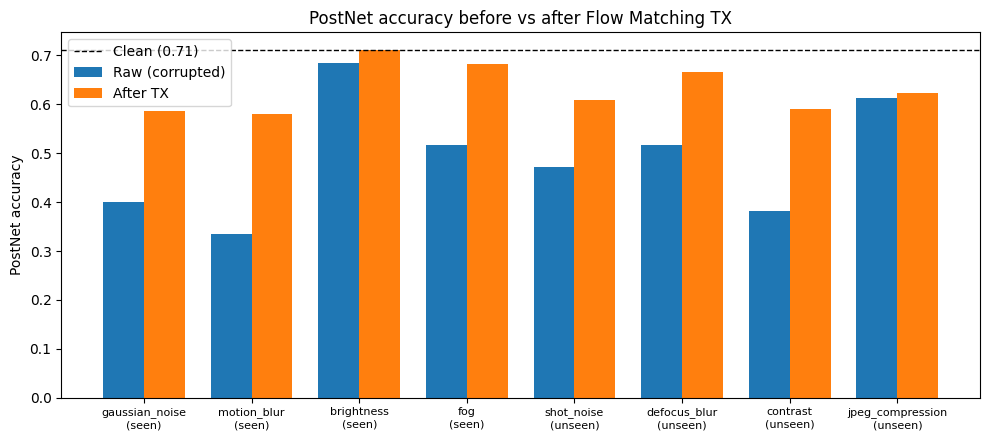

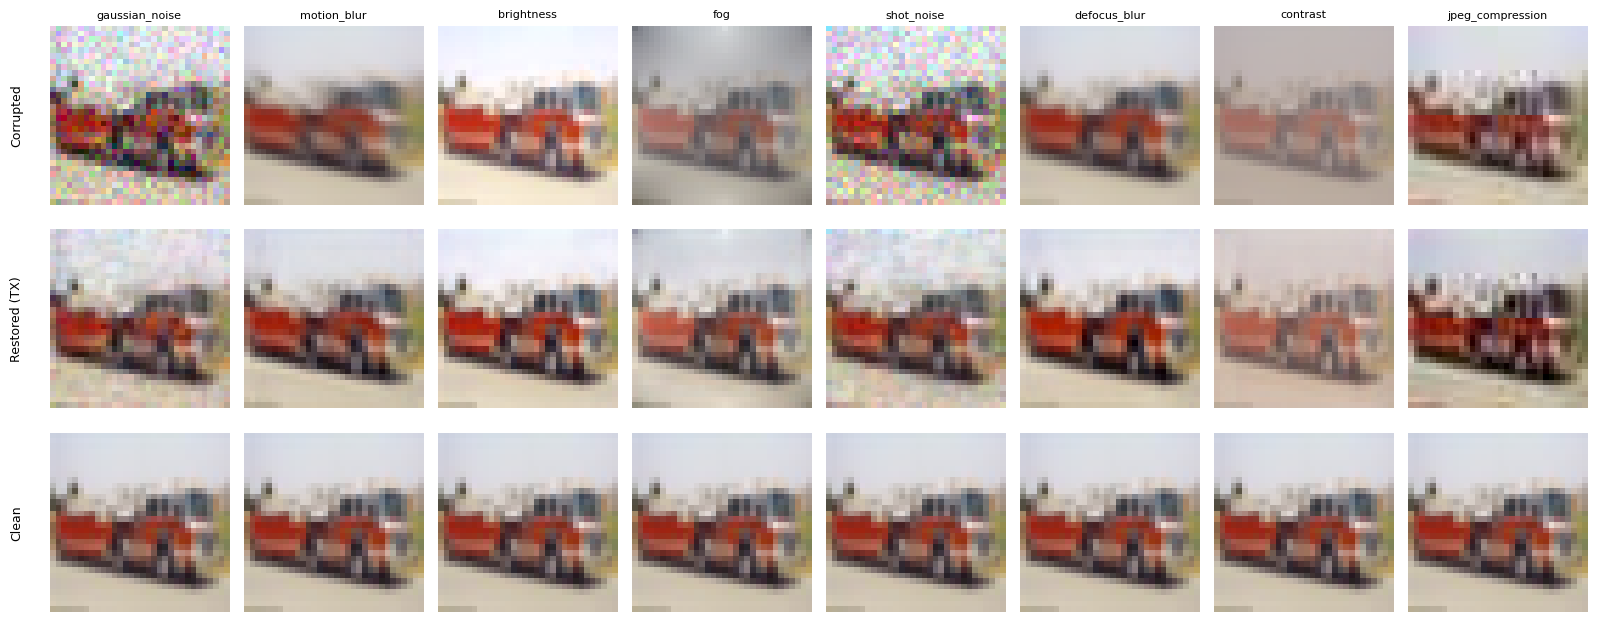

In [16]:
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt

OUT = "/kaggle/working/flowpost_output"
os.makedirs(OUT, exist_ok=True)
vc, vy = val_clean.cpu(), val_y.cpu()

# ---- 1. results table ----
rows = []
for c in SEEN + UNSEEN:
    a_r, e_r = run_postnet(val[c], vy)
    a_f, e_f = run_postnet(restored[c], vy)
    rows.append(dict(
        corruption=c, type="seen" if c in SEEN else "unseen",
        psnr_raw=psnr(val[c], vc), psnr_restored=psnr(restored[c], vc),
        acc_raw=a_r, acc_restored=a_f,
        epi_raw=e_r.mean().item(), epi_restored=e_f.mean().item()))
df = pd.DataFrame(rows).round(4)
df.to_csv(f"{OUT}/phase3_results.csv", index=False)
print(df.to_string(index=False))

# ---- 2. accuracy bar chart ----
x = np.arange(len(df)); w = 0.38
plt.figure(figsize=(10, 4.5))
plt.bar(x - w/2, df.acc_raw, w, label="Raw (corrupted)")
plt.bar(x + w/2, df.acc_restored, w, label="After TX")
plt.axhline(acc_cl, color="k", ls="--", lw=1, label=f"Clean ({acc_cl:.2f})")
plt.xticks(x, [f"{c}\n({t})" for c, t in zip(df.corruption, df.type)], fontsize=8)
plt.ylabel("PostNet accuracy"); plt.title("PostNet accuracy before vs after Flow Matching TX")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUT}/phase3_accuracy_bar.png", dpi=150); plt.show()

# ---- 3. before / after image grid (image #0 of each corruption) ----
names = SEEN + UNSEEN
fig, ax = plt.subplots(3, len(names), figsize=(2 * len(names), 6.5))
def show(a, img, title=None):
    a.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy()); a.axis("off")
    if title: a.set_title(title, fontsize=8)
for j, c in enumerate(names):
    show(ax[0, j], val[c][0], c)
    show(ax[1, j], restored[c][0])
    show(ax[2, j], vc[0])
for i, lab in enumerate(["Corrupted", "Restored (TX)", "Clean"]):
    ax[i, 0].text(-0.15, 0.5, lab, transform=ax[i, 0].transAxes,
                  rotation=90, va="center", ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT}/phase3_image_grid.png", dpi=150); plt.show()

In [17]:
!pip install pgmpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 16.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.3 MB/s eta 0:00:00


In [19]:
import numpy as np, pandas as pd, torch
try:
    from pgmpy.models import DiscreteBayesianNetwork as BN
except ImportError:
    from pgmpy.models import BayesianNetwork as BN
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

vy = val_y.cpu()

@torch.no_grad()
def get_preds(x, bs=500):
    cls, epi, alea = [], [], []
    for i in range(0, len(x), bs):
        p = post.predict(x[i:i + bs].to(DEVICE))
        cls.append(p["pred_class"].cpu())
        epi.append(p["epistemic"].cpu())
        alea.append(p["aleatoric"].cpu())
    return torch.cat(cls), torch.cat(epi).numpy(), torch.cat(alea).numpy()

# --- "high" thresholds come from CLEAN data (95th / 75th percentile) ---
_, epi_c, alea_c = get_preds(val_clean.cpu())
EPI_T, ALEA_T = np.percentile(epi_c, 95), np.percentile(alea_c, 75)
print(f"thresholds: epistemic > {EPI_T:.4f}, aleatoric > {ALEA_T:.4f}")

def build_df(names):
    parts = []
    for c in names:
        raw_cls, _, _ = get_preds(val[c])
        res_cls, epi, alea = get_preds(restored[c])
        parts.append(pd.DataFrame(dict(
            corruption=c,
            Correct=(res_cls == vy).numpy().astype(int),
            Epi=(epi > EPI_T).astype(int),
            Alea=(alea > ALEA_T).astype(int),
            Agree=(raw_cls == res_cls).numpy().astype(int))))
    return pd.concat(parts, ignore_index=True)

train_df, test_df = build_df(SEEN), build_df(UNSEEN)
cols = ["Correct", "Epi", "Alea", "Agree"]

# --- Bayesian network: Correct -> each signal ---
model = BN([("Correct", "Epi"), ("Correct", "Alea"), ("Correct", "Agree")])
est = BayesianEstimator(model, train_df[cols])
cpds = est.get_parameters(prior_type="BDeu", equivalent_sample_size=10)
model.add_cpds(*cpds)
assert model.check_model()
infer = VariableElimination(model)

# --- utilities: (if prediction correct, if wrong). Tune these! ---
U = {"Trust": (1.0, -4.0), "Flag": (0.6, -1.5), "Reject": (-0.5, -0.5)}

def best_action(p):
    eu = {a: p * u[0] + (1 - p) * u[1] for a, u in U.items()}
    return max(eu, key=eu.get)

# --- decision table: every combination of signals ---
policy, rows = {}, []
for e in (0, 1):
    for a in (0, 1):
        for g in (0, 1):
            q = infer.query(["Correct"], evidence={"Epi": e, "Alea": a, "Agree": g},
                            show_progress=False)
            p = float(q.values[1])
            act = best_action(p)
            policy[(e, a, g)] = act
            rows.append(dict(epi_high=e, alea_high=a, agree=g,
                             P_correct=round(p, 3), action=act))
dec = pd.DataFrame(rows)
print(dec.to_string(index=False))

# --- evaluate on UNSEEN corruptions ---
def realized(action, correct):
    u = U[action]
    return u[0] if correct else u[1]

test_df["action"] = [policy[(e, a, g)] for e, a, g in
                     zip(test_df.Epi, test_df.Alea, test_df.Agree)]
test_df["utility"] = [realized(ac, c) for ac, c in zip(test_df.action, test_df.Correct)]
test_df["utility_always_trust"] = [realized("Trust", c) for c in test_df.Correct]

out = []
for c, g in test_df.groupby("corruption"):
    trusted = g[g.action == "Trust"]
    out.append(dict(
        corruption=c,
        acc_all=round(g.Correct.mean(), 3),
        pct_trust=round((g.action == "Trust").mean() * 100, 1),
        pct_flag=round((g.action == "Flag").mean() * 100, 1),
        pct_reject=round((g.action == "Reject").mean() * 100, 1),
        acc_when_trusted=round(trusted.Correct.mean(), 3) if len(trusted) else np.nan,
        utility_policy=round(g.utility.mean(), 3),
        utility_always_trust=round(g.utility_always_trust.mean(), 3)))
res = pd.DataFrame(out)
print("\n", res.to_string(index=False))

dec.to_csv("/kaggle/working/flowpost_output/stage3_decision_table.csv", index=False)
res.to_csv("/kaggle/working/flowpost_output/stage3_unseen_results.csv", index=False)

thresholds: epistemic > 0.0368, aleatoric > 0.5487
 epi_high  alea_high  agree  P_correct action
        0          0      0      0.706   Flag
        0          0      1      0.777   Flag
        0          1      0      0.356 Reject
        0          1      1      0.445 Reject
        1          0      0      0.463 Reject
        1          0      1      0.556   Flag
        1          1      0      0.166 Reject
        1          1      1      0.224 Reject

       corruption  acc_all  pct_trust  pct_flag  pct_reject  acc_when_trusted  utility_policy  utility_always_trust
        contrast    0.590        0.0      68.2        31.8               NaN          -0.174                -1.050
    defocus_blur    0.666        0.0      71.0        29.0               NaN          -0.047                -0.672
jpeg_compression    0.624        0.0      66.5        33.5               NaN          -0.130                -0.882
      shot_noise    0.610        0.0      69.8        30.2               

/tmp/ipykernel_58/378425860.py:44: FutureWarning: `pgmpy.estimators.BayesianEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteBayesianEstimator` instead.
  est = BayesianEstimator(model, train_df[cols])


In [20]:
p_tab = {(r.epi_high, r.alea_high, r.agree): r.P_correct for r in dec.itertuples()}

def run_policy(wrong_pen, df=test_df):
    Ux = {"Trust": (1.0, -wrong_pen), "Flag": (0.6, -1.5), "Reject": (-0.5, -0.5)}
    c = df.Correct.values
    act = []
    for e, a, g in zip(df.Epi, df.Alea, df.Agree):
        p = p_tab[(e, a, g)]
        eu = {k: p * u[0] + (1 - p) * u[1] for k, u in Ux.items()}
        act.append(max(eu, key=eu.get))
    act = np.array(act)
    util = np.array([Ux[x][0] if ci else Ux[x][1] for x, ci in zip(act, c)])
    def acc(name):
        m = act == name
        return round(c[m].mean(), 3) if m.any() else np.nan
    return dict(
        wrong_penalty=wrong_pen,
        pct_trust=round((act == "Trust").mean() * 100, 1),
        pct_flag=round((act == "Flag").mean() * 100, 1),
        pct_reject=round((act == "Reject").mean() * 100, 1),
        acc_trust=acc("Trust"), acc_flag=acc("Flag"), acc_reject=acc("Reject"),
        util_policy=round(util.mean(), 3),
        util_always_trust=round(np.where(c == 1, 1.0, -wrong_pen).mean(), 3),
        util_always_flag=round(np.where(c == 1, 0.6, -1.5).mean(), 3))

sweep = pd.DataFrame([run_policy(w) for w in (1, 2, 2.5, 3, 4)])
print("overall accuracy on unseen:", round(test_df.Correct.mean(), 3))
print(sweep.to_string(index=False))
sweep.to_csv("/kaggle/working/flowpost_output/stage3_sensitivity.csv", index=False)

overall accuracy on unseen: 0.622
 wrong_penalty  pct_trust  pct_flag  pct_reject  acc_trust  acc_flag  acc_reject  util_policy  util_always_trust  util_always_flag
           1.0       95.0       0.0         5.0      0.637       NaN       0.345        0.235              0.244            -0.194
           2.0       68.9       0.0        31.1      0.731       NaN       0.381       -0.022             -0.134            -0.194
           2.5       54.1      14.8        31.1      0.734     0.722       0.381       -0.117             -0.323            -0.194
           3.0        0.0      68.9        31.1        NaN     0.731       0.381       -0.131             -0.511            -0.194
           4.0        0.0      68.9        31.1        NaN     0.731       0.381       -0.131             -0.889            -0.194


In [21]:
import os
for f in sorted(os.listdir("/kaggle/working/flowpost_output")):
    print(f, os.path.getsize(f"/kaggle/working/flowpost_output/{f}"), "bytes")

phase3_accuracy_bar.png 51959 bytes
phase3_image_grid.png 106728 bytes
phase3_results.csv 560 bytes
stage3_decision_table.csv 188 bytes
stage3_sensitivity.csv 384 bytes
stage3_unseen_results.csv 288 bytes


In [22]:
import shutil
shutil.make_archive("/kaggle/working/flowpost_results", "zip", "/kaggle/working/flowpost_output")
print("done")

done


In [23]:
import shutil, os
shutil.copy("/kaggle/working/tx_rebuilt.pt", "/kaggle/working/flowpost_output/flow_matching_tx.pt")
shutil.make_archive("/kaggle/working/flowpost_results_v2", "zip", "/kaggle/working/flowpost_output")
print(os.path.getsize("/kaggle/working/flowpost_output/flow_matching_tx.pt") / 1e6, "MB")

2.264669 MB
